In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cmdstanpy import CmdStanModel

import arviz as az

/home/taliyah/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using the 2026 dataset: https://memory.psych.upenn.edu/Data_Archive#2026

In [9]:
# Get data
data = pd.read_csv('data/Exp2_AllData.csv', header=0, sep=',')
data.head()
data = data[~np.isnan(data["Output_Rank"])]

# Convert to ints
data["Listnum"] = data["Listnum"].astype(int)
data["Spatial_Input_Position"] = data["Spatial_Input_Position"].astype(int)
data["Temporal_Input_Position"] = data["Temporal_Input_Position"].astype(int)
data["Spatial_Recall_Order"] = data["Spatial_Recall_Order"].astype(int)
data["Length"] = data["Length"].astype(int)
data["Correct"] = data["Correct"].astype(int)
data["Distance_From_Correct"] = data["Distance_From_Correct"].astype(int)
data["Serial_Pos_Encoded"] = data["Serial_Pos_Encoded"].astype(int)
data["Output_Rank"] = data["Output_Rank"].astype(int)


# Only use a fraction of the data
train_percent = 0.3
train_n = int(data.shape[0]*train_percent)
data = data.sample(n=train_n)

modif = {}
newv = []
for strin in (data["Condition"].values):
    if not(strin in modif.keys()):
        if len(modif) != 0:
            modif[strin] = modif[max(modif, key=modif.get)]+1
        else:
            modif[strin] = 1
        newv.append(modif[strin])
    else:
        newv.append(modif[strin])
    


data_dict = {
    # Sizes
    "N": data.shape[0],
    # Experiment
    
    "spatial_input_order": pow(np.array((data.Spatial_Input_Position.values.astype(float) - (data.Length.values+1)/(2))/((data.Length.values+1)/(2))),2),
    "temporal_input_pos": np.array((data.Temporal_Input_Position.values.astype(float) - (data.Length.values+1)/(2))/((data.Length.values+1)/(2))),
    "lengthh": np.array((data.Length.values - 4)/4).astype(int),
    # Results
    "correct": data.Correct.values,
    #"output_rank": data.Output_Rank.values,
    "rt": data.Initial_RT_Time.values,
    "type": np.array(newv),
}

In [ ]:
max(np.array(newv))

In [11]:
pow(np.array((data.Spatial_Input_Position.values.astype(float) - (data.Length.values+1)/(2))/(data.Length.values+1)/(2)),2)

array([0.02995562, 0.00540657, 0.02995562, ..., 0.0181213 , 0.00036982,
       0.00924556], shape=(51145,))

In [25]:
# Compile model
# Model based off of figure 7 from the paper
model = CmdStanModel(stan_file="stan/model.stan")

17:50:03 - cmdstanpy - INFO - compiling stan file /mnt/c/Users/inter/CompOrg/TinyCC/stan/model.stan to exe file /mnt/c/Users/inter/CompOrg/TinyCC/stan/model
17:50:16 - cmdstanpy - INFO - compiled model executable: /mnt/c/Users/inter/CompOrg/TinyCC/stan/model


In [26]:
# Sample model
fit = model.sample(data=data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

# Display sampling diagnostics
print(fit.diagnose())

17:50:34 - cmdstanpy - INFO - CmdStan start processing




chain 1:   0%|                                                                       | 0/3500 [00:00<?, ?it/s, (Warmup)]




chain 2:   0%|                                                                       | 0/3500 [00:00<?, ?it/s, (Warmup)]





chain 3:   0%|                                                                       | 0/3500 [00:00<?, ?it/s, (Warmup)]






chain 4:   0%|                                                                       | 0/3500 [00:00<?, ?it/s, (Warmup)]



chain 1:   0%|                                                               | 1/3500 [00:00<15:53,  3.67it/s, (Warmup)]




chain 2:   0%|                                                               | 1/3500 [00:00<16:07,  3.62it/s, (Warmup)]






chain 4:   0%|                                                               | 1/3500 [00:00<16:11,  3.60it/s, (Warmup)]





chain 3:   0%|                                               

18:01:41 - cmdstanpy - INFO - CmdStan done processing.


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [27]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-27084.400000,0.060556,4.205500,4.131260,-27091.700000,-27084.000000,-27078.100000,4818.63,7324.37,3.93895,1.000080
"params[1,1,1]",-1.499810,0.000492,0.054582,0.055045,-1.589730,-1.499730,-1.410350,12436.20,8182.91,10.16590,1.000250
"params[1,1,2]",1.549370,0.015577,1.676240,1.654380,-1.180020,1.550510,4.318340,11627.60,8055.51,9.50491,1.000350
"params[1,1,3]",0.134057,0.003219,0.359087,0.364961,-0.448437,0.131171,0.728751,12515.70,6958.51,10.23080,0.999805
"params[1,2,1]",-1.830830,0.000469,0.051135,0.051667,-1.915090,-1.830050,-1.747100,11861.10,7657.29,9.69580,1.000230
"params[1,2,2]",-0.833177,0.014552,1.614480,1.624700,-3.469080,-0.838636,1.829590,12327.30,8673.79,10.07680,1.000100
"params[1,2,3]",-0.167114,0.002479,0.315677,0.312811,-0.680407,-0.164862,0.351739,16262.90,7896.19,13.29400,1.000440
"params[1,3,1]",-1.956640,0.000435,0.047158,0.046710,-2.033390,-1.956620,-1.878950,11769.50,8147.39,9.62093,1.000560
"params[1,3,2]",-1.149350,0.013994,1.522280,1.495400,-3.685630,-1.147360,1.369680,11867.80,8123.01,9.70123,1.000230
"params[1,3,3]",-0.549750,0.002421,0.278022,0.274976,-1.002320,-0.547784,-0.092247,13303.80,7679.61,10.87510,1.000090


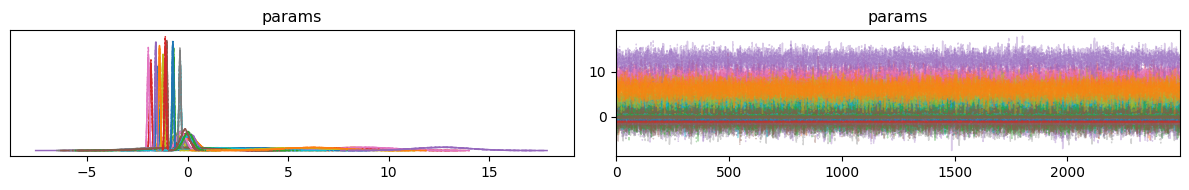

In [28]:
axarr = az.plot_trace(fit.draws_xr("params"))
plt.tight_layout()

In [32]:
def fun(a1,b1,b2,point, order, length):
    return a1 + b1*((point-(length+1)/2)/(length+1)/2)**2 + b2*(order-(length+1)/2)/(length+1)/2

Current TYPE is
['temporal, read aloud']
of Length:
8


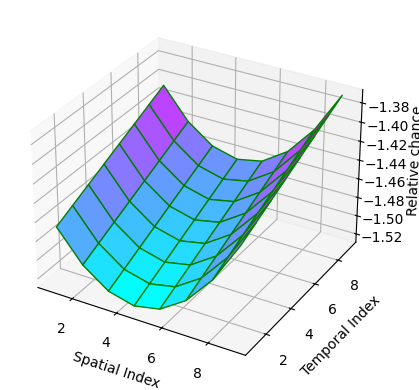

Current TYPE is
['temporal, read aloud']
of Length:
12


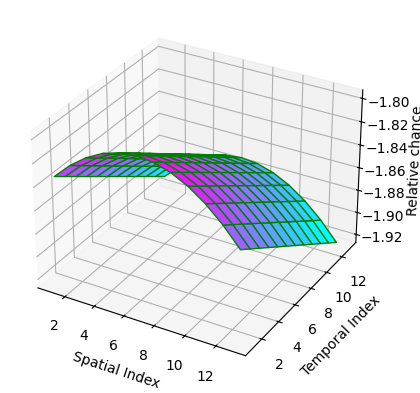

Current TYPE is
['temporal, read aloud']
of Length:
16


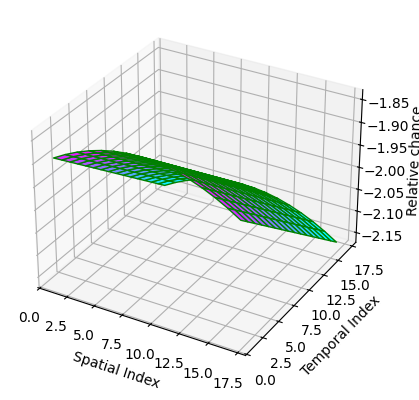

Current TYPE is
['spatial, read aloud']
of Length:
8


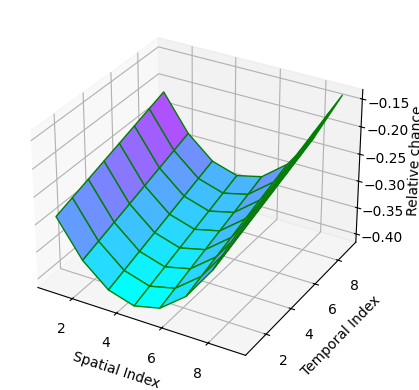

Current TYPE is
['spatial, read aloud']
of Length:
12


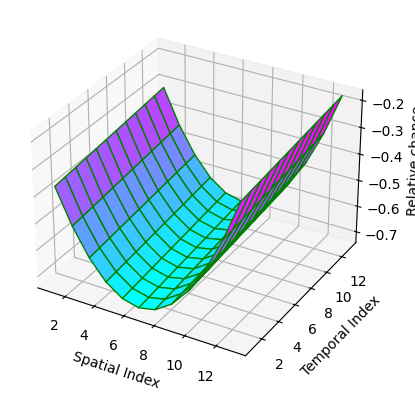

Current TYPE is
['spatial, read aloud']
of Length:
16


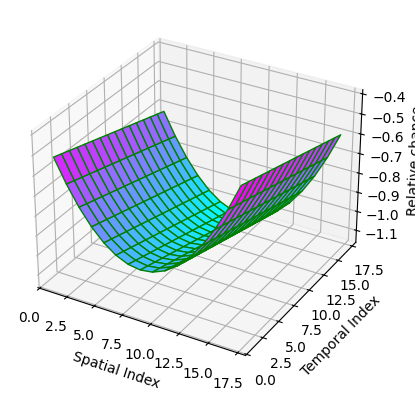

Current TYPE is
['temporal, read silently']
of Length:
8


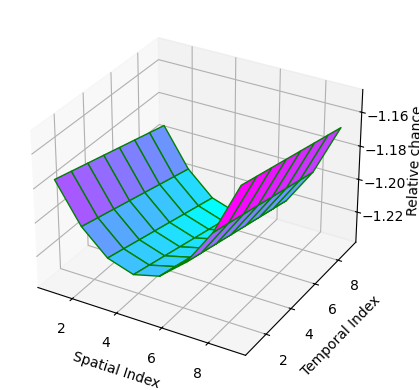

Current TYPE is
['temporal, read silently']
of Length:
12


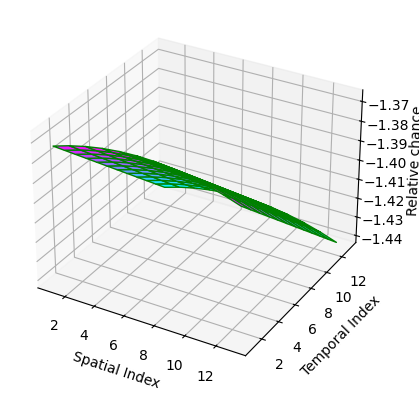

Current TYPE is
['temporal, read silently']
of Length:
16


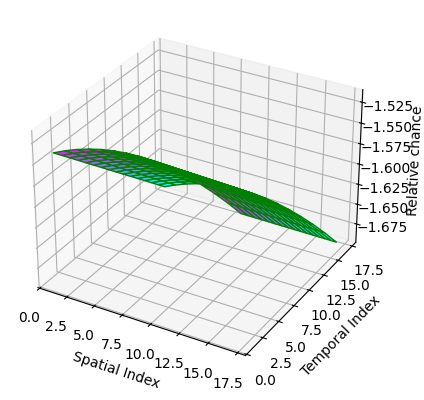

Current TYPE is
['spatial, read silently']
of Length:
8


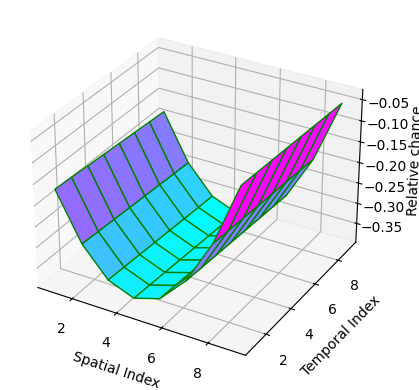

Current TYPE is
['spatial, read silently']
of Length:
12


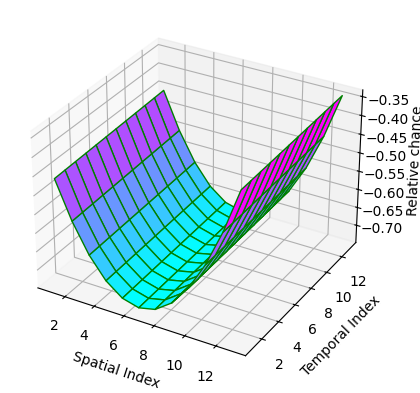

Current TYPE is
['spatial, read silently']
of Length:
16


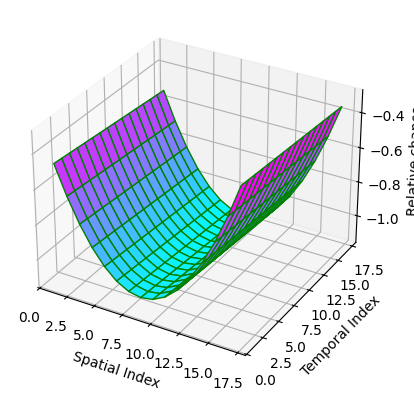

In [34]:
parameters = fit.stan_variable("params").mean(axis=0)

for zpem in range(0,4):
    for leng in range(0,3):
        print("Current TYPE is")
        print([key for key, val in modif.items() if val == zpem+1])
        print("of Length:")
        print(leng*4 + 8)
        x = np.linspace(1,leng*4 + 9,leng*4 + 8)
        y = np.linspace(1,leng*4 + 9,leng*4 + 8)
        vv = parameters[zpem,leng]
        X, Y = np.meshgrid(x, y)
        z = fun(vv[0], vv[1], vv[2], X, Y, (leng*4+8))
        fig = plt.figure()
        ax = plt.axes(projection='3d')
        ax.plot_surface(X, Y, z, cmap='cool', edgecolor='green')
        ax.set_xlabel('Spatial Index')
        ax.set_ylabel('Temporal Index')
        ax.set_zlabel('Relative chance')
        plt.show()
    

In [ ]:
#In the graphings of the model above, I used a bernoulli_logit_lpmf which doesnt directly perscribe probability potentials onto data
#instead, giving relative contributions to the probabilty
#this allows us to analyze the patterns while not constraining the datas
#I had attempted to get an actual probability out of it by normalizing and shifting the data but STAN did not 
#allow the bounds to be within [0,1]

#From this data we can see that for temporal data, the temporal index plays a far bigger role than the spatial one. 
#It tends to increase when the temporal index increases.
#this makes sense due to the recency bias being a thing that influences how a person remembers data
#however, sometimes (like in the length 8 temporal silent) spatial takes a far greater role
#That may be due to applying the same model to all types of analysis, which led to the temporal studies
#considering spatial to have a far greater affect than it actually does in the data.

#this shows the problems with applying a single type of modeto a study which has multiple different ways of getting data
#where each change makes its own variable study